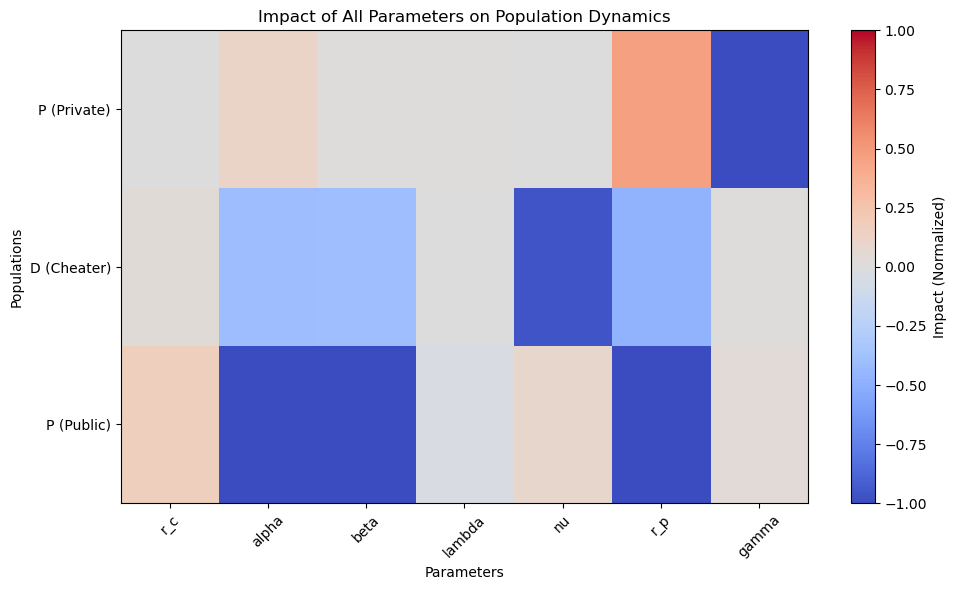

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and ranges
parameters = {
    'r_c': 0.5,
    'alpha': 0.1,
    'beta': 0.05,
    'lambda': 0.02,
    'nu': 0.03,
    'r_p': 0.4,
    'gamma': 0.02,
}

# Initial conditions
C0, D0, P0 = 10, 10, 10  # Initial populations
t_max = 100  # Simulation time
dt = 0.1  # Time step
n_steps = int(t_max / dt)

# Function to simulate population dynamics
def calculate_population_dynamics(params):
    C, D, P = C0, D0, P0
    total_C, total_D, total_P = 0, 0, 0

    for _ in range(n_steps):
        # Differential equations
        dC = params['r_c'] * C - params['alpha'] * C * D - params['beta'] * C * P - params['lambda'] * C**2
        dD = params['alpha'] * C * D - params['nu'] * D**2
        dP = params['r_p'] * P - params['beta'] * P * C - params['gamma'] * P**2

        # Update populations
        C += dC * dt
        D += dD * dt
        P += dP * dt

        # Accumulate positive populations
        total_C += max(C, 0) * dt
        total_D += max(D, 0) * dt
        total_P += max(P, 0) * dt

    return total_C, total_D, total_P

# Baseline dynamics
baseline_C, baseline_D, baseline_P = calculate_population_dynamics(parameters)

# Parameter perturbation range
rc_rp_range = np.linspace(0.1, 1.0, 10)  # Range for parameters

# Initialize impact matrix
parameter_names = list(parameters.keys())
impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

# Metabolic control analysis
for j, param_name in enumerate(parameter_names):
    impacts = []

    for factor in rc_rp_range:
        perturbed_params = parameters.copy()
        perturbed_params[param_name] *= factor
        perturbed_C, perturbed_D, perturbed_P = calculate_population_dynamics(perturbed_params)

        # Calculate relative impacts for populations
        impacts.append([
            (baseline_C - perturbed_C) / baseline_C,
            (baseline_D - perturbed_D) / baseline_D ,
            (baseline_P - perturbed_P ) / baseline_P,
        ])

    # Average impact over the range
    impact_matrix[:, j] = np.mean(impacts, axis=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin= -1, vmax=1)
plt.colorbar(label='Impact (Normalized)')
plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
plt.yticks(range(3), labels=['P (Public)', 'D (Cheater)', 'P (Private)'])
plt.title('Impact of All Parameters on Population Dynamics')
plt.xlabel('Parameters')
plt.ylabel('Populations')
plt.tight_layout()
plt.show()


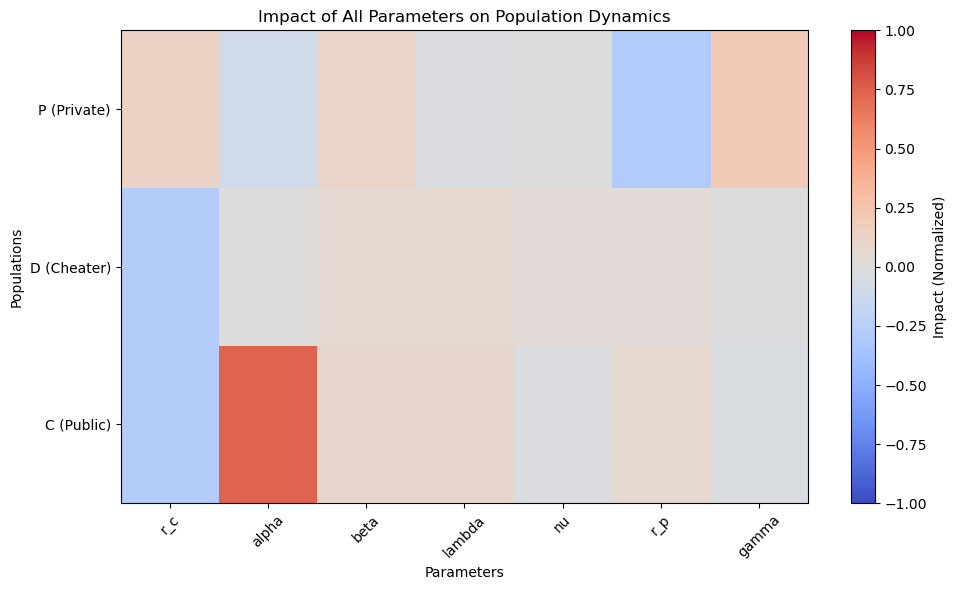

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters and ranges
parameters = {
    'r_c': 0.04,
    'alpha': 0.0002,
    'beta': 0.0001,
    'lambda': 0.0001,
    'nu': 0.00001,
    'r_p': 0.02,
    'gamma': 0.0001,
}

# Initial conditions
C0, D0, P0 = 100, 100, 100  # Initial populations
t_max = 100  # Simulation time
dt = 0.1  # Time step
n_steps = int(t_max / dt)

# Function to simulate population dynamics
def calculate_population_dynamics(params):
    C, D, P = C0, D0, P0
    total_C, total_D, total_P = 0, 0, 0

    for _ in range(n_steps):
        # Differential equations
        dC = params['r_c'] * C - params['alpha'] * C * D - params['beta'] * C * P - params['lambda'] * C**2
        dD = params['alpha'] * C * D - params['nu'] * D**2
        dP = params['r_p'] * P - params['beta'] * P * C - params['gamma'] * P**2

        # Update populations
        C += dC * dt
        D += dD * dt
        P += dP * dt

        # Accumulate positive populations
        total_C += max(C, 0) * dt
        total_D += max(D, 0) * dt
        total_P += max(P, 0) * dt

    return total_C, total_D, total_P

# Baseline dynamics
baseline_C, baseline_D, baseline_P = calculate_population_dynamics(parameters)

# Parameter perturbation range
rc_rp_range = np.linspace(2, 1.0, 10)  # Range for parameters

# Initialize impact matrix
parameter_names = list(parameters.keys())
impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

# Metabolic control analysis
for j, param_name in enumerate(parameter_names):
    impacts = []

    for factor in rc_rp_range:
        perturbed_params = parameters.copy()
        perturbed_params[param_name] *= factor
        perturbed_C, perturbed_D, perturbed_P = calculate_population_dynamics(perturbed_params)

        # Calculate relative impacts for populations
        impacts.append([
            (perturbed_C -baseline_C ) /  perturbed_C,
            (baseline_D - perturbed_D) / perturbed_D ,
            (baseline_P - perturbed_P ) / perturbed_P,
        ])

    # Average impact over the range
    impact_matrix[:, j] = np.mean(impacts, axis=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin= -1, vmax=1)
plt.colorbar(label='Impact (Normalized)')
plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
plt.yticks(range(3), labels=['C (Public)', 'D (Cheater)', 'P (Private)'])
plt.title('Impact of All Parameters on Population Dynamics')
plt.xlabel('Parameters')
plt.ylabel('Populations')
plt.tight_layout()
plt.show()




### Starting Equation for Relative Abundance (\(x\)):
\[
x = \frac{C}{N}, \quad \text{where } N = C + D + P.
\]

The derivative of \(x\) is:
\[
x' = \frac{d}{dt}\left(\frac{C}{N}\right) = \frac{N \cdot \frac{dC}{dt} - C \cdot \frac{dN}{dt}}{N^2}.
\]

Here:
- \(\frac{dC}{dt} = r_c C - \alpha C D - \beta C P - \lambda C^2\),
- \(\frac{dD}{dt} = \alpha C D - \nu D^2\),
- \(\frac{dP}{dt} = r_p P - \beta C P - \gamma P^2\),
- \(\frac{dN}{dt} = \frac{dC}{dt} + \frac{dD}{dt} + \frac{dP}{dt}\).


### Substituting into \(x'\):
\[
x' = \frac{1}{N^2} \left( N \cdot \frac{dC}{dt} - C \cdot \frac{dN}{dt} \right).
\]

Substitute \(\frac{dC}{dt}\) and \(\frac{dN}{dt}\):
\[
x' = \frac{1}{N^2} \Bigg[ N \cdot \big(r_c C - \alpha C D - \beta C P - \lambda C^2 \big) - C \cdot \big( \frac{dC}{dt} + \frac{dD}{dt} + \frac{dP}{dt} \big) \Bigg].
\]

---

### Expand \(\frac{dN}{dt}\):
Substituting \(\frac{dN}{dt} = \frac{dC}{dt} + \frac{dD}{dt} + \frac{dP}{dt}\), we get:
\[
\frac{dN}{dt} = \big(r_c C - \alpha C D - \beta C P - \lambda C^2\big) + \big(\alpha C D - \nu D^2\big) + \big(r_p P - \beta C P - \gamma P^2\big).
\]

Simplify:
\[
\frac{dN}{dt} = r_c C + r_p P - \lambda C^2 - \nu D^2 - \gamma P^2 - \beta C P.
\]

---

### Substituting Back:
Substituting \(\frac{dC}{dt}\) and \(\frac{dN}{dt}\) into \(x'\):
\[
x' = \frac{1}{N^2} \Bigg[ N \cdot \big(r_c C - \alpha C D - \beta C P - \lambda C^2\big) - C \cdot \big(r_c C + r_p P - \lambda C^2 - \nu D^2 - \gamma P^2 - \beta C P\big) \Bigg].
\]

---

### Expanding Terms:
Expand the terms inside the brackets:
\[
x' = \frac{1}{N^2} \Bigg[ \big(N r_c C - N \alpha C D - N \beta C P - N \lambda C^2\big)
- \big(C r_c C + C r_p P - C \lambda C^2 - C \nu D^2 - C \gamma P^2 - C \beta C P\big) \Bigg].
\]

Group similar terms:
\[
x' = \frac{1}{N^2} \Bigg[
r_c C N - \alpha C D N - \beta C P N - \lambda C^2 N
- r_c C^2 - r_p C P + \lambda C^3 + \nu C D^2 + \gamma C P^2 + \beta C^2 P
\Bigg].
\]

---

### Final Expression:
Rewriting:
\[
x' = \frac{1}{N^2} \Big[
C \big( r_c N - \alpha D N - \beta P N - \lambda C N - r_c C - r_p P + \lambda C^2 + \nu D^2 + \gamma P^2 + \beta C P \big)
\Big].
\]

This is the detailed, elaborated computation of \(x'\) directly from the equations. If you need any step clarified further, let me know!